Project Topic:Early Disease Detection with Explainable AI

IMPORT LIBRARIES

In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

DATA READING

In [54]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [55]:
df=pd.read_csv("/content/drive/MyDrive/Diabetes_prediction.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Diagnosis
0,2,115.863387,56.410731,24.336736,94.385783,26.455940,0.272682,20.100494,0
1,2,92.490122,70.615520,23.443591,138.652426,23.910167,0.665160,44.912281,0
2,1,88.141469,63.262618,23.404364,149.358082,21.948250,0.676022,48.247873,1
3,2,108.453101,67.793632,20.751580,108.751638,24.209304,0.289636,42.749868,0
4,1,127.849443,94.725685,22.603078,25.269987,32.997477,0.601315,32.797789,0


DATA UNDERSTAND

In [56]:
#shape
print(df.shape)
#data type
df.dtypes

(1000, 9)


,0
Pregnancies,int64
Glucose,float64
BloodPressure,float64
SkinThickness,float64
Insulin,float64
BMI,float64
DiabetesPedigreeFunction,float64
Age,float64
Diagnosis,int64


In [57]:
#check the null values
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Diagnosis,0


In [58]:
#basic information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               1000 non-null   int64  
 1   Glucose                   1000 non-null   float64
 2   BloodPressure             1000 non-null   float64
 3   SkinThickness             1000 non-null   float64
 4   Insulin                   1000 non-null   float64
 5   BMI                       1000 non-null   float64
 6   DiabetesPedigreeFunction  1000 non-null   float64
 7   Age                       1000 non-null   float64
 8   Diagnosis                 1000 non-null   int64  
dtypes: float64(7), int64(2)
memory usage: 70.4 KB


In [59]:
#statistical summary of numerical variables
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Diagnosis
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000
mean,1.771000,99.440607,72.179837,23.278316,84.582679,25.433600,0.449383,43.281798,0.30600
std,1.354398,19.470730,13.882017,1.173807,74.872733,3.690223,0.199334,14.465398,0.46106
min,0.000000,30.571402,31.401487,19.369987,-165.310033,13.548818,0.100037,-0.979804,0.00000
25%,1.000000,86.145927,62.795447,22.501591,35.076535,23.022715,0.283376,33.518451,0.00000
50%,2.000000,99.458362,71.909588,23.275225,84.442232,25.455649,0.448219,43.634273,0.00000
75%,3.000000,113.264556,82.082660,24.052022,134.267842,27.972184,0.619158,53.098446,1.00000
max,8.000000,161.238939,110.723715,26.917654,317.701852,36.324598,0.799654,90.573782,1.00000


<Axes: >

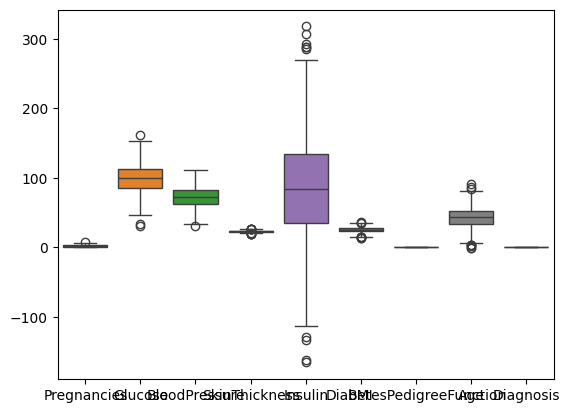

In [60]:
#Check for outliers
import seaborn as sns
sns.boxplot(data=df)

In [61]:
#CHECK IMBALANCED DATA
df['Diagnosis'].value_counts()

,count
Diagnosis,
0,694
1,306


DATA CLEANING

In [62]:
from sklearn.model_selection import train_test_split
#SPLIT
X = df.drop('Diagnosis', axis=1)
y = df['Diagnosis']

#TRAIN
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [63]:
#Apply preprocessing ONLY on train
cols = ['Glucose', 'BloodPressure', 'BMI', 'SkinThickness']

for col in cols:
    median_val = X_train[X_train[col] > 0][col].median()
 # Handle Age & Insulin.
    X_train.loc[X_train[col] <= 0, col] = median_val
    X_test.loc[X_test[col] <= 0, col] = median_val   # use TRAIN median
median_insulin = X_train[X_train['Insulin'] > 0]['Insulin'].median()

X_train.loc[X_train['Insulin'] <= 0, 'Insulin'] = median_insulin
X_test.loc[X_test['Insulin'] <= 0, 'Insulin'] = median_insulin
df = df[df['Age'] > 0]

In [64]:
#outlier handling
cols = ['Glucose', 'BloodPressure', 'BMI', 'Insulin']

for col in cols:
    Q1 =  X_train[col].quantile(0.25)
    Q3 =  X_train[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    X_train[col] = X_train[col].clip(lower, upper)
    X_test[col]  = X_test[col].clip(lower, upper)

EDA

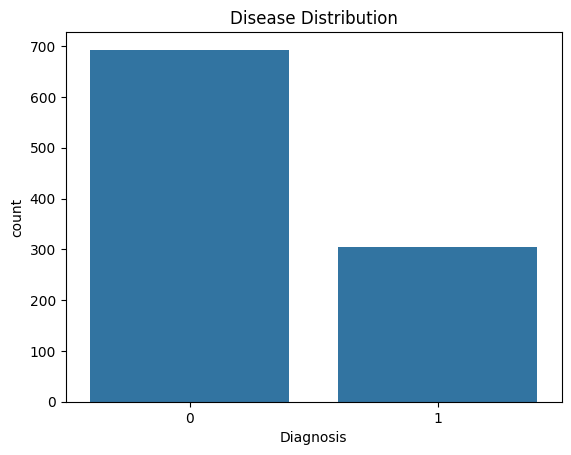

In [65]:
#CHECK TARGET DISTRIBUTION
import seaborn as sns
import matplotlib.pyplot as plt
sns.countplot(x='Diagnosis', data=df)
plt.title("Disease Distribution")
plt.show()

#Count of 0 (No Disease)
#Count of 1 (Disease)

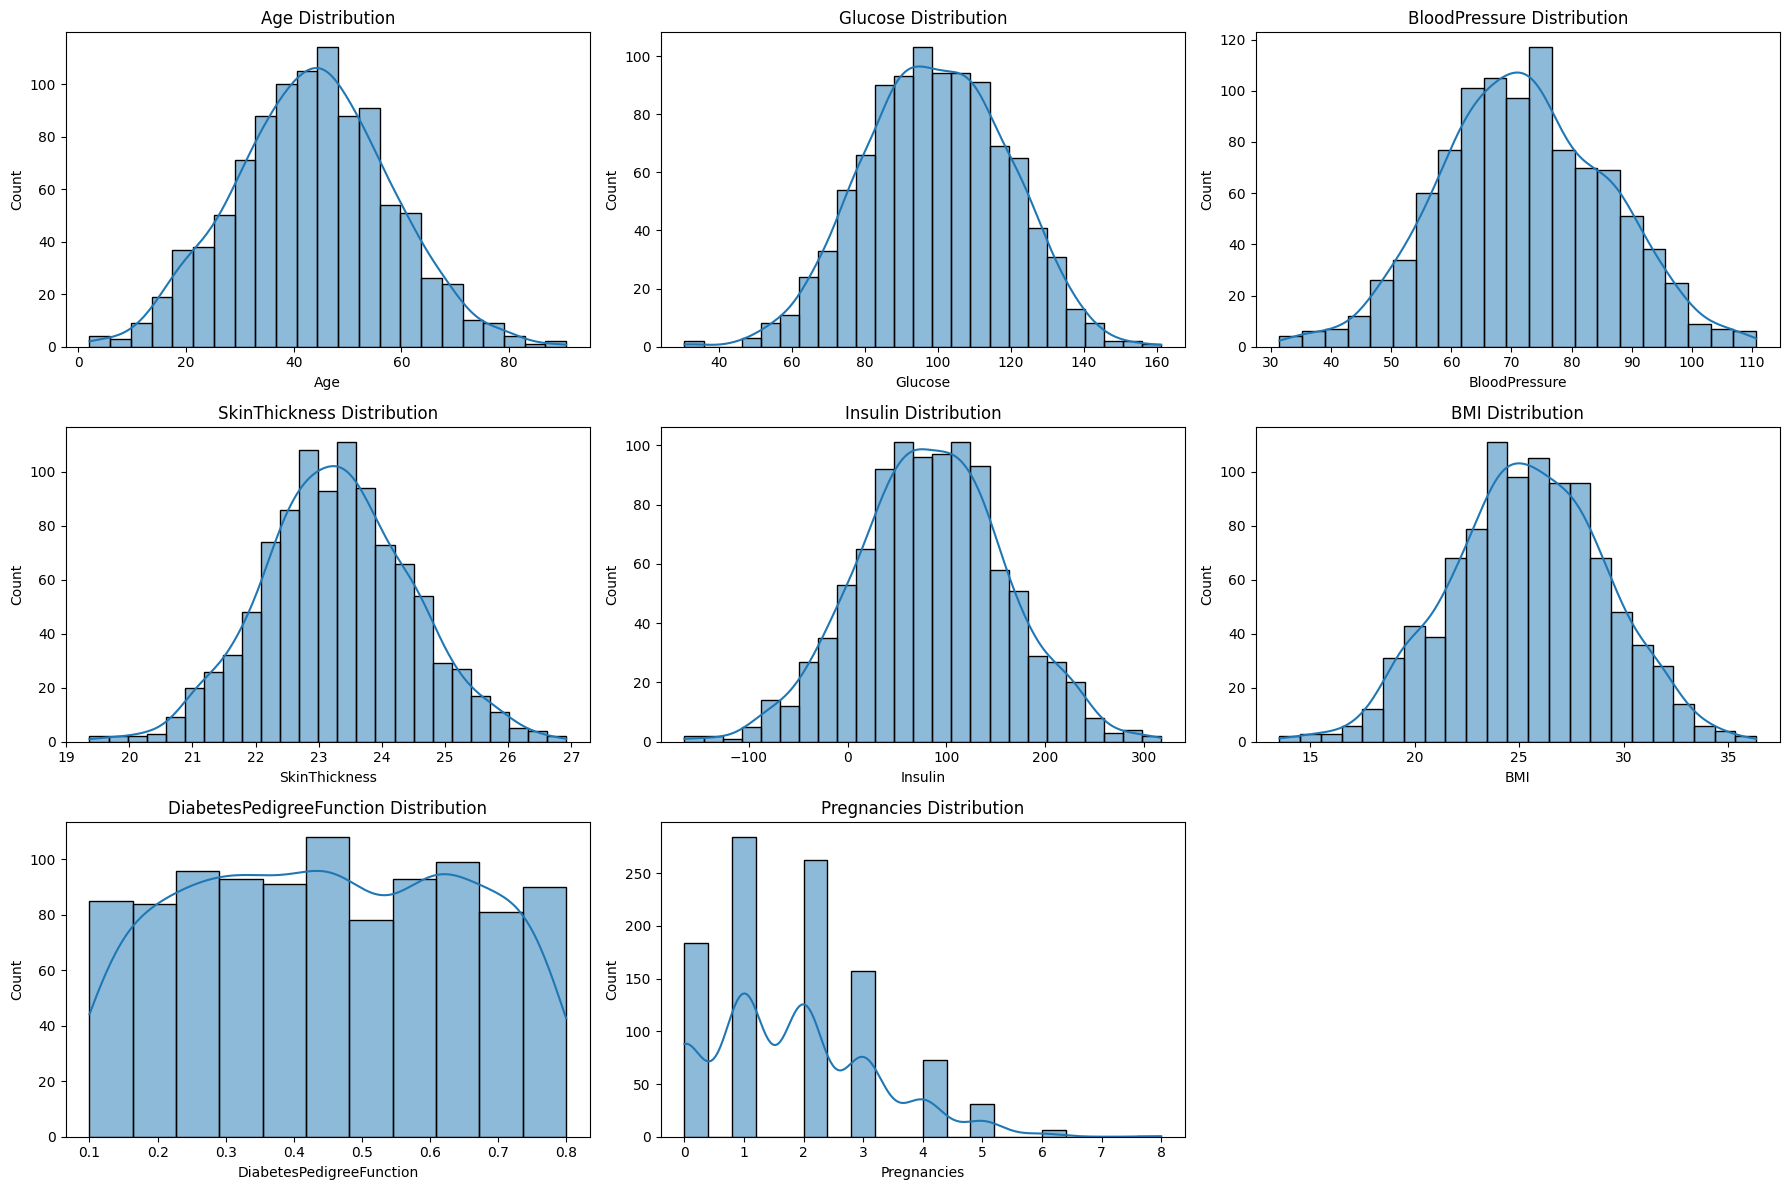

In [66]:
#UNIVARIATE ANALYSIS
plt.figure(figsize=(18,12))

plt.subplot(3,3,1)
sns.histplot(df['Age'], kde=True)
plt.title("Age Distribution")

plt.subplot(3,3,2)
sns.histplot(df['Glucose'], kde=True)
plt.title("Glucose Distribution")

plt.subplot(3,3,3)
sns.histplot(df['BloodPressure'], kde=True)
plt.title("BloodPressure Distribution")

plt.subplot(3,3,4)
sns.histplot(df['SkinThickness'], kde=True)
plt.title("SkinThickness Distribution")

plt.subplot(3,3,5)
sns.histplot(df['Insulin'], kde=True)
plt.title("Insulin Distribution")

plt.subplot(3,3,6)
sns.histplot(df['BMI'], kde=True)
plt.title("BMI Distribution")

plt.subplot(3,3,7)
sns.histplot(df['DiabetesPedigreeFunction'], kde=True)
plt.title("DiabetesPedigreeFunction Distribution")

plt.subplot(3,3,8)
sns.histplot(df['Pregnancies'], kde=True)
plt.title("Pregnancies Distribution")

plt.tight_layout()
plt.show()

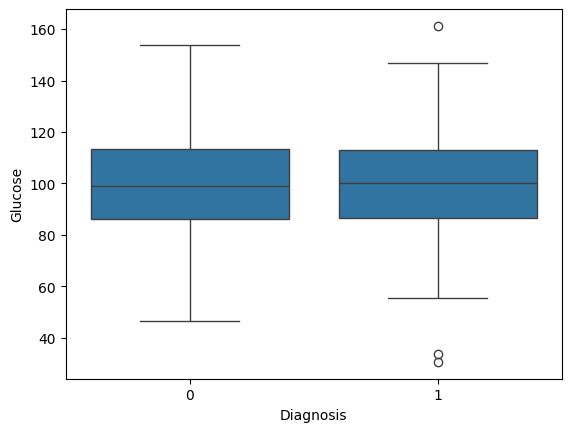

In [67]:
#BIVARIATE ANALYSIS
#Glucose vs Diagnosis
sns.boxplot(x='Diagnosis', y='Glucose', data=df)
plt.show()

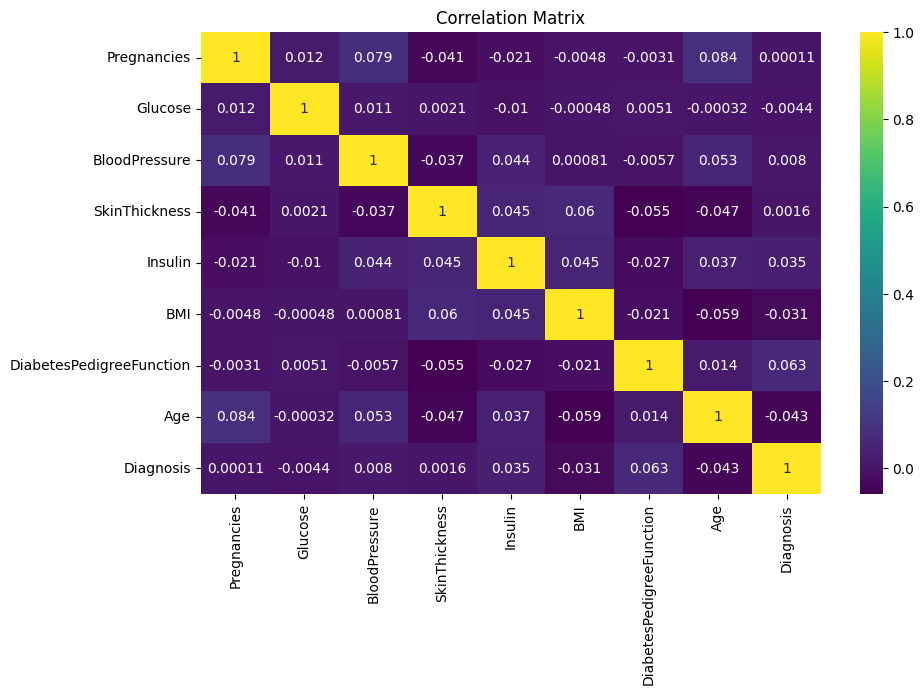

In [68]:
#CORRELATION ANALYSIS
#relationship between all features
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='viridis')
plt.title("Correlation Matrix")
plt.show()

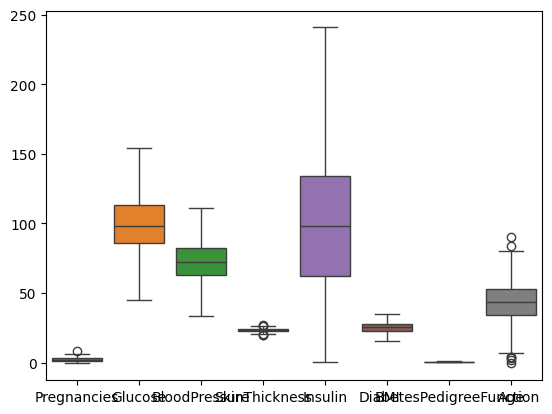

In [69]:
#OUTLIER ANALYSIS
sns.boxplot(data=X_train)
plt.show()

PIPELINE

In [70]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

In [71]:
print("Class distribution in y_train:")
print(y_train.value_counts())

# Calculate the actual scale_pos_weight
neg_count = y_train.value_counts()[0]
pos_count = y_train.value_counts()[1]
calculated_scale_pos_weight = neg_count / pos_count

print(f"\nCalculated scale_pos_weight (neg/pos): {calculated_scale_pos_weight:.2f}")

Class distribution in y_train:
Diagnosis
0    555
1    245
Name: count, dtype: int64

Calculated scale_pos_weight (neg/pos): 2.27


MODEL BUILDING

In [72]:
pipelines = {
    "Logistic Regression": ImbPipeline([
        ('smote', SMOTE(random_state=42)),
        ('scaler', StandardScaler()),
        ('model', LogisticRegression())
    ]),

    "Decision Tree": ImbPipeline([
        ('smote', SMOTE(random_state=42)),
        ('model', DecisionTreeClassifier())
    ]),

    "Random Forest": ImbPipeline([
        ('smote', SMOTE(random_state=42)),
        ('model', RandomForestClassifier())
    ]),

    "KNN": ImbPipeline([
        ('smote', SMOTE(random_state=42)),
        ('scaler', StandardScaler()),
        ('model', KNeighborsClassifier())
    ]),

    "XGBoost": ImbPipeline([
        ('smote', SMOTE(random_state=42)),
        ('model', XGBClassifier(
            scale_pos_weight=calculated_scale_pos_weight,
            eval_metric='logloss',
            random_state=42
        ))
    ])
}

Evaluate All Pipelines

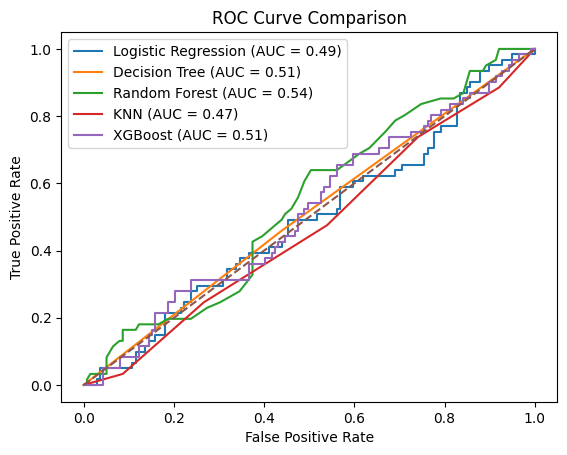

In [73]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
from sklearn.metrics import confusion_matrix
results = []

plt.figure()

for name, pipeline in pipelines.items():
    # Train model
    pipeline.fit(X_train, y_train)

    # Predictions
    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]  # for ROC

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)
    cm = confusion_matrix(y_test, y_pred)

    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1 Score": f1,
        "ROC-AUC": roc_auc,
        "Confusion Matrix":cm
    })

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")


# Plot settings
plt.plot([0, 1], [0, 1], linestyle='--')  # random model
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

In [74]:
#Show Results as Table
result_df=pd.DataFrame(results)
print(result_df)

                 Model  Accuracy  Precision    Recall  F1 Score   ROC-AUC  \
0  Logistic Regression     0.525   0.315217  0.475410  0.379085  0.492039   
1        Decision Tree     0.530   0.314607  0.459016  0.373333  0.510084   
2        Random Forest     0.560   0.263158  0.245902  0.254237  0.541337   
3                  KNN     0.465   0.278846  0.475410  0.351515  0.467803   
4              XGBoost     0.530   0.285714  0.360656  0.318841  0.514683   

       Confusion Matrix  
0  [[76, 63], [32, 29]]  
1  [[78, 61], [33, 28]]  
2  [[97, 42], [46, 15]]  
3  [[64, 75], [32, 29]]  
4  [[84, 55], [39, 22]]  


In [75]:
from sklearn.model_selection import cross_val_score

# Use the pipelines directly as they are already defined and contain the models
models = pipelines

cv_results = {}

for name, model in models.items():
    # cross_val_score can accept a pipeline as an estimator
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='f1')
    cv_results[name] = scores.mean()
    print(f"{name} Mean F1 Score: {scores.mean():.4f}")

Logistic Regression Mean F1 Score: 0.3797
Decision Tree Mean F1 Score: 0.3415
Random Forest Mean F1 Score: 0.2652
KNN Mean F1 Score: 0.3826
XGBoost Mean F1 Score: 0.3350


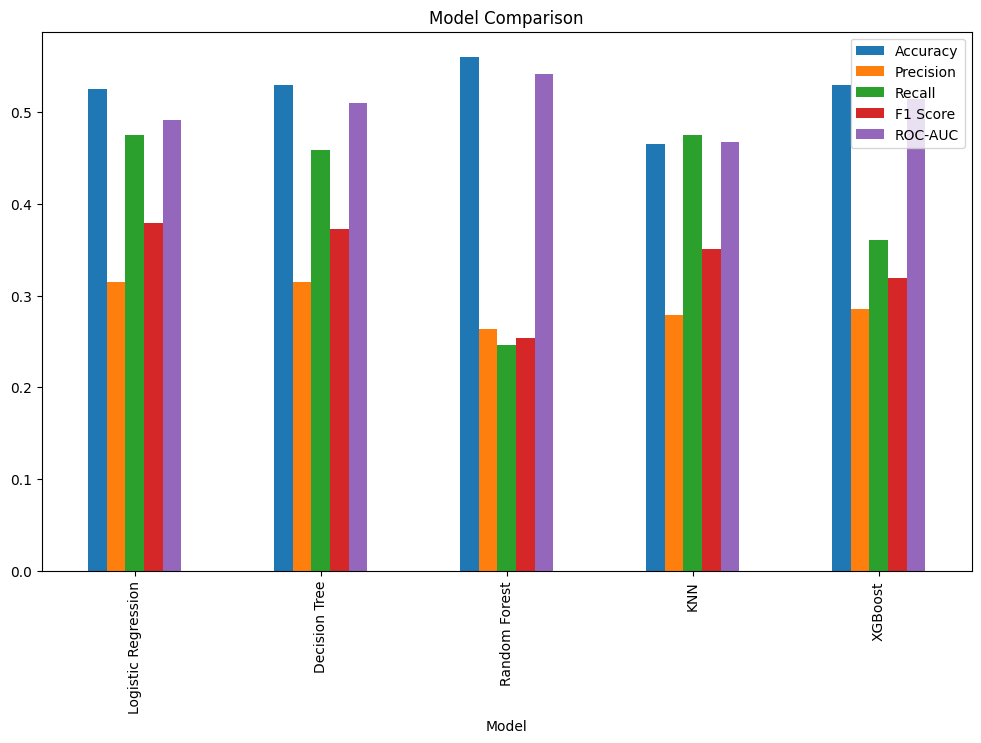

In [77]:
result_df.set_index('Model')[['Accuracy','Precision','Recall','F1 Score','ROC-AUC']].plot(kind='bar',figsize=(12,7))
plt.title("Model Comparison")
plt.show()

In [78]:
#Classification Report
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.68      0.60      0.64       139
           1       0.29      0.36      0.32        61

    accuracy                           0.53       200
   macro avg       0.48      0.48      0.48       200
weighted avg       0.56      0.53      0.54       200



HYPERPARAMETERS TUNING

In [79]:
#Define Parameter Grid
param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [3, 5],
    'model__learning_rate': [0.01, 0.1],
    'model__subsample': [0.8, 1],
    'model__colsample_bytree': [0.8, 1]
}

In [80]:
#Apply GridSearch on Pipeline
from sklearn.model_selection import GridSearchCV

grid = GridSearchCV(
    pipelines["XGBoost"],   # your pipeline
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

In [81]:
#Train
grid.fit(X_train, y_train)

Fitting 5 folds for each of 32 candidates, totalling 160 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('smote', SMOTE(random_state=42)),
                                       ('model',
                                        XGBClassifier(base_score=None,
                                                      booster=None,
                                                      callbacks=None,
                                                      colsample_bylevel=None,
                                                      colsample_bynode=None,
                                                      colsample_bytree=None,
                                                      device=None,
                                                      early_stopping_rounds=None,
                                                      enable_categorical=False,
                                                      eval_metric='logloss',
                                                      feature_types=None,
                                                      feature_weights=None,
                                                      gamma=None,
                                                      gr...
                                                      max_leaves=None,
                                                      min_child_weight=None,
                                                      missing=nan,
                                                      monotone_constraints=None,
                                                      multi_strategy=None,
                                                      n_estimators=None,
                                                      n_jobs=None,
                                                      num_parallel_tree=None, ...))]),
             n_jobs=-1,
             param_grid={'model__colsample_bytree': [0.8, 1],
                         'model__learning_rate': [0.01, 0.1],
                         'model__max_depth': [3, 5],
                         'model__n_estimators': [100, 200],
                         'model__subsample': [0.8, 1]},
             scoring='f1', verbose=1)

In [82]:
#Best Parameters
print("Best Parameters:", grid.best_params_)

Best Parameters: {'model__colsample_bytree': 0.8, 'model__learning_rate': 0.01, 'model__max_depth': 3, 'model__n_estimators': 200, 'model__subsample': 1}


In [83]:
#Best Model
best_model = grid.best_estimator_

Final Evaluation

In [84]:
#Make Prediction
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

In [85]:
#Recalculate All Metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print(f"""
After Tuning:
Accuracy : {accuracy:.4f}
Precision: {precision:.4f}
Recall   : {recall:.4f}
F1 Score : {f1:.4f}
ROC-AUC  : {roc_auc:.4f}
""")


After Tuning:
Accuracy : 0.3550
Precision: 0.3111
Recall   : 0.9180
F1 Score : 0.4647
ROC-AUC  : 0.5543



Among all models, XGBoost achieved the highest F1-score and ROC-AUC after hyperparameter tuning, making it the most effective model for handling imbalanced medical classification.

In [86]:
#Compare Before vs After
# Get the metrics for XGBoost before tuning from result_df
xgb_metrics_before = result_df[result_df['Model'] == 'XGBoost'].iloc[0]

acc_old = xgb_metrics_before['Accuracy']
prec_old = xgb_metrics_before['Precision']
rec_old = xgb_metrics_before['Recall']
f1_old = xgb_metrics_before['F1 Score']
auc_old = xgb_metrics_before['ROC-AUC']

comparison = {
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"],
    "Before Tuning": [acc_old, prec_old, rec_old, f1_old, auc_old],
    "After Tuning": [accuracy, precision, recall, f1, roc_auc]
}

import pandas as pd
print(pd.DataFrame(comparison))

      Metric  Before Tuning  After Tuning
0   Accuracy       0.530000      0.355000
1  Precision       0.285714      0.311111
2     Recall       0.360656      0.918033
3   F1 Score       0.318841      0.464730
4    ROC-AUC       0.514683      0.554311


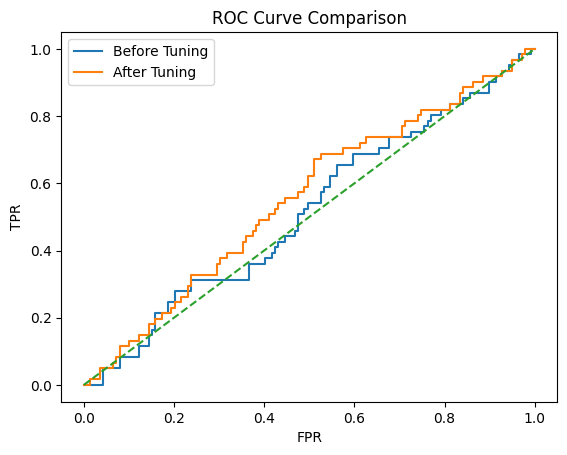

In [87]:
#ROC Curve (Before vs After)
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

# Before tuning
y_prob_old = pipelines["XGBoost"].fit(X_train, y_train).predict_proba(X_test)[:,1]
fpr_old, tpr_old, _ = roc_curve(y_test, y_prob_old)

# After tuning
fpr_new, tpr_new, _ = roc_curve(y_test, y_prob)

plt.plot(fpr_old, tpr_old, label="Before Tuning")
plt.plot(fpr_new, tpr_new, label="After Tuning")


plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

Feature Importance

In [88]:
model = best_model.named_steps['model']

import pandas as pd
import matplotlib.pyplot as plt

importance = model.feature_importances_
features = X.columns

df_imp = pd.DataFrame({
    "Feature": features,
    "Importance": importance
}).sort_values(by="Importance", ascending=False)

print(df_imp)

                    Feature  Importance
7                       Age    0.169193
6  DiabetesPedigreeFunction    0.143567
3             SkinThickness    0.122732
5                       BMI    0.122665
2             BloodPressure    0.122636
0               Pregnancies    0.120988
4                   Insulin    0.117740
1                   Glucose    0.080480


EXPLAINABLE AI

SHAP

SHAP was used to interpret the model by identifying feature contributions. It provided both global and local explanations, improving transparency of the XGBoost model.

In [89]:
#INSTALL & IMPORT
!pip install shap
import shap

In [90]:
#CREATE EXPLAINER
explainer = shap.Explainer(model, X_train)

In [91]:
#GENERATE SHAP VALUES
shap_values = explainer(X_test)

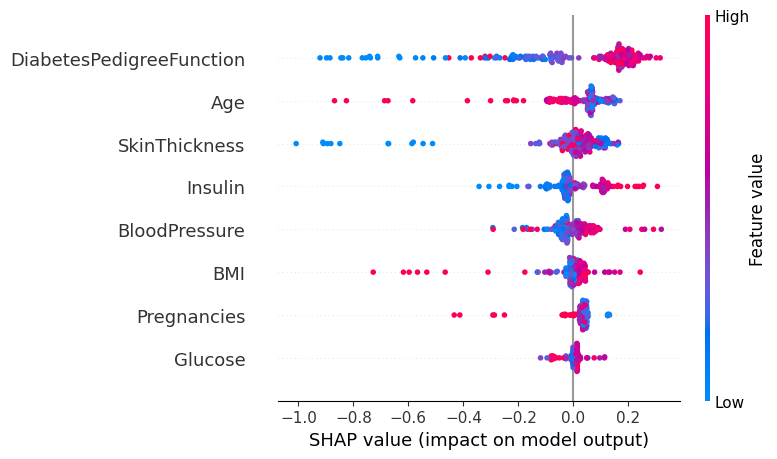

In [92]:
#SUMMARY PLOT
shap.summary_plot(shap_values, X_test)

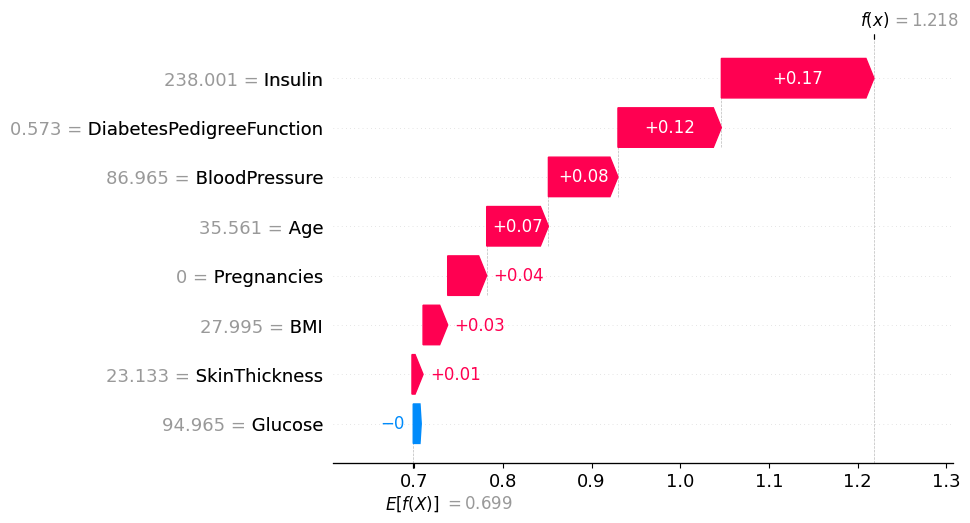

In [93]:
shap.plots.waterfall(shap_values[0])

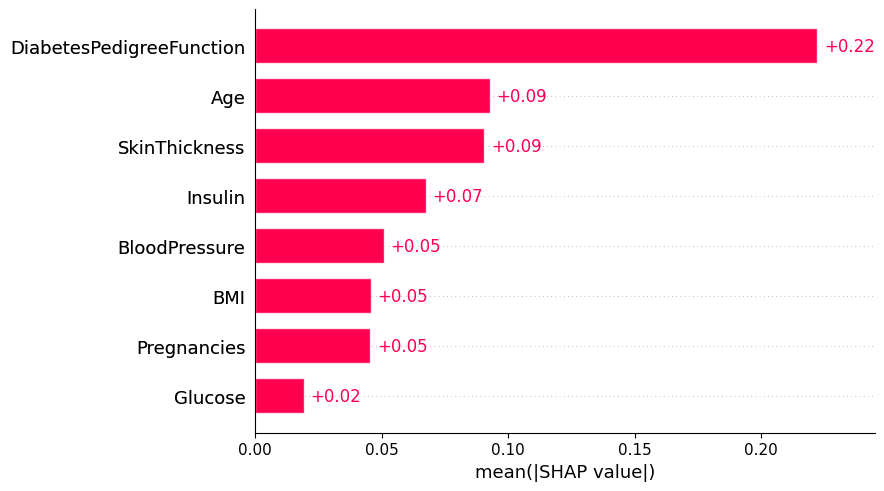

In [94]:
#FEATURE IMPORTANCE
shap.plots.bar(shap_values)


In [95]:
#Individual Prediction Explanation
#Shows:Why ONE prediction happened

# Initialize Javascript for SHAP visualizations
shap.initjs()
shap.force_plot(
    explainer.expected_value,
    shap_values[0].values, # Access the numerical SHAP values
    X_test.iloc[0]
)

LIME

This patient is predicted positive because feature A ↑, feature B ↓

In [96]:
#Install & Import LIME
!pip install lime
from lime.lime_tabular import LimeTabularExplainer

In [97]:
#Prepare Data
import numpy as np

X_train_np = X_train.values
X_test_np = X_test.values

In [98]:
#Create Explainer
explainer = LimeTabularExplainer(
    training_data=X_train_np,
    feature_names=X.columns.tolist(),
    class_names=['No Disease', 'Disease'],
    mode='classification'
)

In [99]:
#Define Prediction Function
predict_fn = lambda x: best_model.predict_proba(x)

In [100]:
#Explain One Prediction
exp = explainer.explain_instance(
    X_test_np[0],        # first sample
    predict_fn,
    num_features=10
)

In [101]:
#Show Explanation
#Option 1 (Notebook View)
exp.show_in_notebook(show_table=True)

LIME was used to provide local interpretability by explaining individual predictions. It highlights feature contributions for specific instances, complementing SHAP which provides global explanations.